In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

# Scikit-Learn (Makine Öğrenmesi) Kütüphaneleri
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print(">>> SVM Deneyleri için tüm kütüphaneler başarıyla yüklendi!")

>>> SVM Deneyleri için tüm kütüphaneler başarıyla yüklendi!


In [2]:
# Veri setinin ana dizini
# DİKKAT: Burayı kendi bilgisayarınızdaki dataset klasörünün tam yolu ile değiştirin!
# Örnek: DATASET_DIR = "C:/Users/isim/Desktop/XRay_SVM_Project/dataset"
DATASET_DIR = "../dataset" 

CATEGORIES = ["COVID", "Normal", "Viral Pneumonia"]
IMG_SIZE = 100 # SVM için boyutları biraz küçültmek hesaplama süresini inanılmaz hızlandırır.

data = []
labels = []

print(">>> Veriler okunuyor ve düzleştiriliyor (Flattening)... Lütfen bekleyin.")
start_time = time.time()

for category in CATEGORIES:
    path = os.path.join(DATASET_DIR, category)
    class_num = CATEGORIES.index(category) # COVID: 0, Normal: 1, Viral Pneumonia: 2
    
    for img_name in os.listdir(path):
        try:
            # Resmi gri tonlamalı (Grayscale) oku
            img_array = cv2.imread(os.path.join(path, img_name), cv2.IMREAD_GRAYSCALE)
            
            if img_array is not None:
                # Boyutlandır
                resized_img = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
                
                # DÜZLEŞTİRME (FLATTEN): 100x100'lük matrisi 10000 elemanlı tek bir satıra çevirir
                flattened_img = resized_img.flatten()
                
                data.append(flattened_img)
                labels.append(class_num)
        except Exception as e:
            pass

# Listeleri Numpy Array'e çevirme
X = np.array(data)
y = np.array(labels)

# Veriyi 0-1 arasına normalize etme (Çok önemli!)
X = X / 255.0

print(f">>> İşlem tamamlandı! Geçen süre: {round(time.time() - start_time, 2)} saniye.")
print(f"Toplam Görüntü Sayısı: {len(X)}")
print(f"X matrisinin boyutu: {X.shape} -> (Görüntü Sayısı, Her Görüntüdeki Piksel Sayısı)")
print(f"y dizisinin boyutu: {y.shape}")

>>> Veriler okunuyor ve düzleştiriliyor (Flattening)... Lütfen bekleyin.
>>> İşlem tamamlandı! Geçen süre: 0.02 saniye.
Toplam Görüntü Sayısı: 0
X matrisinin boyutu: (0,) -> (Görüntü Sayısı, Her Görüntüdeki Piksel Sayısı)
y dizisinin boyutu: (0,)


In [3]:
import os
import cv2
import numpy as np
import time

# VS Code workspace içindeki göreceli yol (Relative Path)
# Explorer'da gördüğümüz yapıya tam uygun.
DATASET_DIR = "dataset" 

CATEGORIES = ["COVID", "Normal", "Viral Pneumonia"]
IMG_SIZE = 100 

data = []
labels = []

print(f">>> Veri okunacak ana dizin: {os.path.abspath(DATASET_DIR)}")

if not os.path.exists(DATASET_DIR):
    print(f"❌ HATA: '{DATASET_DIR}' klasörü bulunamadı!")
    print("Lütfen VS Code'da doğru klasörü açtığınızdan emin olun.")
else:
    print(">>> Veriler okunuyor ve düzleştiriliyor (Flattening)... Lütfen bekleyin.\n")
    start_time = time.time()

    for category in CATEGORIES:
        path = os.path.join(DATASET_DIR, category)
        class_num = CATEGORIES.index(category) 
        
        if not os.path.exists(path):
            print(f"⚠️ UYARI: '{category}' klasörü bulunamadı! Yol: {path}")
            continue

        resim_sayisi = 0
        for img_name in os.listdir(path):
            # Sadece resim dosyalarını oku (excel veya metadata dosyalarını atla)
            if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                try:
                    img_path = os.path.join(path, img_name)
                    img_array = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                    
                    if img_array is not None:
                        resized_img = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
                        flattened_img = resized_img.flatten()
                        data.append(flattened_img)
                        labels.append(class_num)
                        resim_sayisi += 1
                except Exception as e:
                    pass
                    
        print(f"✔️ '{category}' klasöründen {resim_sayisi} adet resim başarıyla yüklendi.")

    X = np.array(data)
    y = np.array(labels)

    if len(X) > 0:
        print("\n>>> Resimler normalize ediliyor (0-1 aralığına çekiliyor)...")
        X = X / 255.0 
        
        print("\n🎉 İŞLEM BAŞARIYLA TAMAMLANDI!")
        print("-" * 40)
        print(f"⏱️ Geçen süre: {round(time.time() - start_time, 2)} saniye.")
        print(f"📊 Toplam Görüntü Sayısı: {len(X)}")
        print(f"📐 X matrisinin boyutu: {X.shape} (Görüntü Sayısı, Piksel Sayısı)")
        print(f"🎯 y dizisinin boyutu: {y.shape}")
        print("-" * 40)
    else:
        print("\n❌ HATA: Klasörler bulundu ancak içinden hiç resim okunamadı.")

>>> Veri okunacak ana dizin: c:\Users\mehmet\Desktop\XRay_SVM_Project\notebooks\dataset
❌ HATA: 'dataset' klasörü bulunamadı!
Lütfen VS Code'da doğru klasörü açtığınızdan emin olun.


In [4]:
import os
import cv2
import numpy as np
import time

# Notebook "notebooks" klasöründe olduğu için "../" ile bir üst dizine çıkıp
# doğru klasör adını (COVID-19_Radiography_Dataset) hedefliyoruz.
DATASET_DIR = "../COVID-19_Radiography_Dataset" 

# Kullanacağımız 3 ana sınıf (Lung_Opacity hariç)
CATEGORIES = ["COVID", "Normal", "Viral Pneumonia"]
IMG_SIZE = 100 

data = []
labels = []

print(f">>> Aranan veri seti yolu: {os.path.abspath(DATASET_DIR)}")

if not os.path.exists(DATASET_DIR):
    print(f"❌ HATA: '{DATASET_DIR}' klasörü bulunamadı!")
    print("Lütfen dosya yolunu kontrol edin.")
else:
    print(">>> Veriler okunuyor ve düzleştiriliyor (Flattening)... Lütfen bekleyin.\n")
    start_time = time.time()

    for category in CATEGORIES:
        path = os.path.join(DATASET_DIR, category)
        class_num = CATEGORIES.index(category) 
        
        if not os.path.exists(path):
            print(f"⚠️ UYARI: '{category}' klasörü bulunamadı! Yol: {path}")
            continue

        resim_sayisi = 0
        for img_name in os.listdir(path):
            # Sadece resim dosyalarını oku (Excel veya text dosyalarını atla)
            if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                try:
                    img_path = os.path.join(path, img_name)
                    img_array = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                    
                    if img_array is not None:
                        # SVM için boyutu 100x100'e küçült
                        resized_img = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
                        # 100x100 matrisi 10.000 elemanlı tek bir satıra (vektöre) çevir
                        flattened_img = resized_img.flatten()
                        
                        data.append(flattened_img)
                        labels.append(class_num)
                        resim_sayisi += 1
                except Exception as e:
                    pass
                    
        print(f"✔️ '{category}' klasöründen {resim_sayisi} adet resim başarıyla yüklendi.")

    # Listeleri Numpy Matrislerine (Array) Çevir
    X = np.array(data)
    y = np.array(labels)

    if len(X) > 0:
        print("\n>>> Resimler normalize ediliyor (0-1 aralığına çekiliyor)...")
        X = X / 255.0 
        
        print("\n🎉 İŞLEM BAŞARIYLA TAMAMLANDI!")
        print("-" * 50)
        print(f"⏱️ Geçen süre: {round(time.time() - start_time, 2)} saniye.")
        print(f"📊 Toplam Görüntü Sayısı: {len(X)}")
        print(f"📐 X matrisinin boyutu: {X.shape} (Görüntü Sayısı, Her Görüntüdeki Piksel Sayısı)")
        print(f"🎯 y dizisinin boyutu: {y.shape}")
        print("-" * 50)
    else:
        print("\n❌ HATA: Klasörler bulundu ancak içinden hiç resim okunamadı.")

>>> Aranan veri seti yolu: c:\Users\mehmet\Desktop\XRay_SVM_Project\COVID-19_Radiography_Dataset
>>> Veriler okunuyor ve düzleştiriliyor (Flattening)... Lütfen bekleyin.

✔️ 'COVID' klasöründen 0 adet resim başarıyla yüklendi.
✔️ 'Normal' klasöründen 0 adet resim başarıyla yüklendi.
✔️ 'Viral Pneumonia' klasöründen 0 adet resim başarıyla yüklendi.

❌ HATA: Klasörler bulundu ancak içinden hiç resim okunamadı.


In [5]:
import os
import cv2
import numpy as np
import time

DATASET_DIR = "../COVID-19_Radiography_Dataset" 

CATEGORIES = ["COVID", "Normal", "Viral Pneumonia"]
IMG_SIZE = 100 

data = []
labels = []

print(f">>> Aranan veri seti yolu: {os.path.abspath(DATASET_DIR)}")

if not os.path.exists(DATASET_DIR):
    print(f"❌ HATA: '{DATASET_DIR}' klasörü bulunamadı!")
    print("Lütfen dosya yolunu kontrol edin.")
else:
    print(">>> Veriler okunuyor ve düzleştiriliyor (Flattening)... Lütfen bekleyin.\n")
    start_time = time.time()

    for category in CATEGORIES:
        path = os.path.join(DATASET_DIR, category)
        class_num = CATEGORIES.index(category) 
        
        if not os.path.exists(path):
            print(f"⚠️ UYARI: '{category}' klasörü bulunamadı! Yol: {path}")
            continue

        resim_sayisi = 0
        # DÜZELTME: os.walk kullanarak tüm alt klasörleri (örn: 'images' klasörünü) de tarıyoruz!
        for root, dirs, files in os.walk(path):
            for img_name in files:
                if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                    try:
                        img_path = os.path.join(root, img_name)
                        img_array = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                        
                        if img_array is not None:
                            # SVM için boyutu 100x100'e küçült
                            resized_img = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
                            # 100x100 matrisi 10.000 elemanlı tek bir satıra (vektöre) çevir
                            flattened_img = resized_img.flatten()
                            
                            data.append(flattened_img)
                            labels.append(class_num)
                            resim_sayisi += 1
                    except Exception as e:
                        pass
                        
        print(f"✔️ '{category}' klasöründen {resim_sayisi} adet resim başarıyla yüklendi.")

    # Listeleri Numpy Matrislerine (Array) Çevir
    X = np.array(data)
    y = np.array(labels)

    if len(X) > 0:
        print("\n>>> Resimler normalize ediliyor (0-1 aralığına çekiliyor)...")
        X = X / 255.0 
        
        print("\n🎉 İŞLEM BAŞARIYLA TAMAMLANDI!")
        print("-" * 50)
        print(f"⏱️ Geçen süre: {round(time.time() - start_time, 2)} saniye.")
        print(f"📊 Toplam Görüntü Sayısı: {len(X)}")
        print(f"📐 X matrisinin boyutu: {X.shape} (Görüntü Sayısı, Her Görüntüdeki Piksel Sayısı)")
        print(f"🎯 y dizisinin boyutu: {y.shape}")
        print("-" * 50)
    else:
        print("\n❌ HATA: Klasörler ve alt klasörler tarandı ancak hiç resim okunamadı.")

>>> Aranan veri seti yolu: c:\Users\mehmet\Desktop\XRay_SVM_Project\COVID-19_Radiography_Dataset
>>> Veriler okunuyor ve düzleştiriliyor (Flattening)... Lütfen bekleyin.

✔️ 'COVID' klasöründen 7232 adet resim başarıyla yüklendi.


KeyboardInterrupt: 

In [6]:
import os
import cv2
import numpy as np
import time

DATASET_DIR = "../COVID-19_Radiography_Dataset" 
CATEGORIES = ["COVID", "Normal", "Viral Pneumonia"]

IMG_SIZE = 100 
MAX_IMAGES_PER_CLASS = 1000 # HER SINIFTAN ALINACAK MAKSİMUM RESİM SAYISI

data = []
labels = []

print(f">>> Aranan veri seti yolu: {os.path.abspath(DATASET_DIR)}")

if not os.path.exists(DATASET_DIR):
    print(f"❌ HATA: '{DATASET_DIR}' klasörü bulunamadı!")
else:
    print(f">>> Veriler okunuyor (Her sınıftan {MAX_IMAGES_PER_CLASS} adet alınacak)... Lütfen bekleyin.\n")
    start_time = time.time()

    for category in CATEGORIES:
        path = os.path.join(DATASET_DIR, category)
        class_num = CATEGORIES.index(category) 
        
        if not os.path.exists(path):
            print(f"⚠️ UYARI: '{category}' klasörü bulunamadı!")
            continue

        resim_sayisi = 0
        for root, dirs, files in os.walk(path):
            for img_name in files:
                # EĞER LİMİTE ULAŞILDIYSA DÖNGÜYÜ DURDUR
                if resim_sayisi >= MAX_IMAGES_PER_CLASS:
                    break
                    
                if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                    try:
                        img_path = os.path.join(root, img_name)
                        img_array = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                        
                        if img_array is not None:
                            resized_img = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
                            flattened_img = resized_img.flatten()
                            
                            data.append(flattened_img)
                            labels.append(class_num)
                            resim_sayisi += 1
                    except Exception as e:
                        pass
            
            # İç döngüden çıkıldıktan sonra dış döngüyü de kontrol et
            if resim_sayisi >= MAX_IMAGES_PER_CLASS:
                break
                        
        print(f"✔️ '{category}' klasöründen {resim_sayisi} adet resim başarıyla yüklendi.")

    # Listeleri Numpy Matrislerine Çevir
    X = np.array(data)
    y = np.array(labels)

    if len(X) > 0:
        print("\n>>> Resimler normalize ediliyor (0-1 aralığına çekiliyor)...")
        X = X / 255.0 
        
        print("\n🎉 İŞLEM BAŞARIYLA TAMAMLANDI!")
        print("-" * 50)
        print(f"⏱️ Geçen süre: {round(time.time() - start_time, 2)} saniye.")
        print(f"📊 Toplam Görüntü Sayısı: {len(X)}")
        print(f"📐 X matrisinin boyutu: {X.shape} (Görüntü Sayısı, Her Görüntüdeki Piksel Sayısı)")
        print(f"🎯 y dizisinin boyutu: {y.shape}")
        print("-" * 50)
    else:
        print("\n❌ HATA: Resim okunamadı.")

>>> Aranan veri seti yolu: c:\Users\mehmet\Desktop\XRay_SVM_Project\COVID-19_Radiography_Dataset
>>> Veriler okunuyor (Her sınıftan 1000 adet alınacak)... Lütfen bekleyin.

✔️ 'COVID' klasöründen 1000 adet resim başarıyla yüklendi.
✔️ 'Normal' klasöründen 1000 adet resim başarıyla yüklendi.
✔️ 'Viral Pneumonia' klasöründen 1000 adet resim başarıyla yüklendi.

>>> Resimler normalize ediliyor (0-1 aralığına çekiliyor)...

🎉 İŞLEM BAŞARIYLA TAMAMLANDI!
--------------------------------------------------
⏱️ Geçen süre: 30.93 saniye.
📊 Toplam Görüntü Sayısı: 3000
📐 X matrisinin boyutu: (3000, 10000) (Görüntü Sayısı, Her Görüntüdeki Piksel Sayısı)
🎯 y dizisinin boyutu: (3000,)
--------------------------------------------------


In [7]:
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# 1. VERİYİ EĞİTİM VE TEST OLARAK BÖLME
# Hocanızın istediği gibi önce klasik %80 Eğitim, %20 Test oranıyla başlıyoruz.
# (Daha sonra bu oranı %70-%30 olarak değiştirip tekrar deneyeceğiz)
test_orani = 0.20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_orani, random_state=42, stratify=y)

print(f">>> Veri Bölme İşlemi Tamamlandı (Test Oranı: %{int(test_orani*100)})")
print(f"Eğitim Seti: {X_train.shape[0]} resim")
print(f"Test Seti: {X_test.shape[0]} resim\n")

# 2. BOYUT İNDİRGEME (PCA) İŞLEMİ
# 10.000 piksel SVM için çok fazladır. En önemli özellikleri (varyansın %95'ini) koruyarak boyutu küçülteceğiz.
print(">>> PCA (Boyut İndirgeme) işlemi başlatılıyor... Lütfen bekleyin.")
start_pca = time.time()

# Varyansın %95'ini koruyacak kadar bileşen (component) seç
pca = PCA(n_components=0.95, random_state=42) 

# PCA modelini sadece EĞİTİM verisiyle eğit ve dönüştür
X_train_pca = pca.fit_transform(X_train)
# Test verisini de aynı PCA modeliyle dönüştür (Asla test verisiyle fit etmiyoruz!)
X_test_pca = pca.transform(X_test)

print(f"✔️ PCA Tamamlandı! Geçen Süre: {round(time.time() - start_pca, 2)} saniye.")
print(f"📉 Orijinal Özellik Sayısı: {X_train.shape[1]} (Piksel)")
print(f"📊 PCA Sonrası Özellik Sayısı: {X_train_pca.shape[1]} (En önemli bileşenler)")

>>> Veri Bölme İşlemi Tamamlandı (Test Oranı: %20)
Eğitim Seti: 2400 resim
Test Seti: 600 resim

>>> PCA (Boyut İndirgeme) işlemi başlatılıyor... Lütfen bekleyin.
✔️ PCA Tamamlandı! Geçen Süre: 8.85 saniye.
📉 Orijinal Özellik Sayısı: 10000 (Piksel)
📊 PCA Sonrası Özellik Sayısı: 187 (En önemli bileşenler)


>>> SVM Kernel (Çekirdek) Deneyleri Başlıyor... (Bu işlem bilgisayarınızın hızına göre 1-2 dakika sürebilir)

⚙️ Eğitiliyor: LINEAR Kernel...
✔️ LINEAR Kernel Tamamlandı! Süre: 1.44 sn | Başarı: %84.33

⚙️ Eğitiliyor: POLY Kernel...
✔️ POLY Kernel Tamamlandı! Süre: 0.18 sn | Başarı: %87.0

⚙️ Eğitiliyor: RBF Kernel...
✔️ RBF Kernel Tamamlandı! Süre: 0.18 sn | Başarı: %89.5



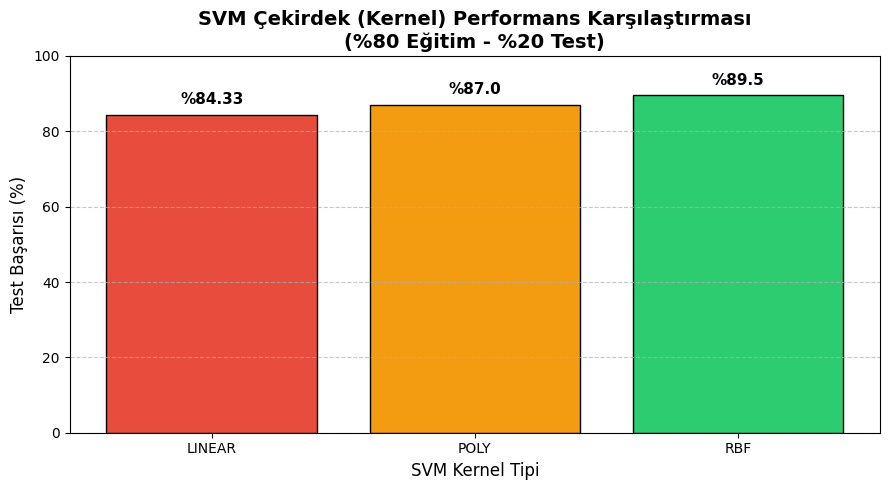

In [8]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

kernels = ['linear', 'poly', 'rbf']
accuracies = []

print(">>> SVM Kernel (Çekirdek) Deneyleri Başlıyor... (Bu işlem bilgisayarınızın hızına göre 1-2 dakika sürebilir)\n")

for k in kernels:
    print(f"⚙️ Eğitiliyor: {k.upper()} Kernel...")
    start_svm = time.time()
    
    # SVM Modelini Tanımla ve Eğit
    svm_model = SVC(kernel=k, random_state=42)
    svm_model.fit(X_train_pca, y_train)
    
    # Test verisi üzerinde tahmin yap
    y_pred = svm_model.predict(X_test_pca)
    
    # Başarıyı hesapla
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc * 100)
    
    print(f"✔️ {k.upper()} Kernel Tamamlandı! Süre: {round(time.time() - start_svm, 2)} sn | Başarı: %{round(acc * 100, 2)}\n")

# --- HOCANIN İSTEDİĞİ KIYASLAMA GRAFİĞİ ÇİZİMİ ---
plt.figure(figsize=(9, 5))
colors = ['#e74c3c', '#f39c12', '#2ecc71'] # Kırmızı (Kötü), Turuncu (Orta), Yeşil (İyi)
bars = plt.bar([k.upper() for k in kernels], accuracies, color=colors, edgecolor='black')

plt.title('SVM Çekirdek (Kernel) Performans Karşılaştırması\n(%80 Eğitim - %20 Test)', fontsize=14, fontweight='bold')
plt.xlabel('SVM Kernel Tipi', fontsize=12)
plt.ylabel('Test Başarısı (%)', fontsize=12)
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Barların üzerine değerleri yaz
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 2, f'%{round(yval, 2)}', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

>>> Eğitim/Test Oranı (Train/Test Split) Deneyleri Başlıyor...

⚙️ Deney 1: %80 Eğitim - %20 Test hazırlanıyor...
✔️ Tamamlandı! PCA Bileşen Sayısı: 187 | Başarı: %89.5

⚙️ Deney 2: %70 Eğitim - %30 Test hazırlanıyor...
✔️ Tamamlandı! PCA Bileşen Sayısı: 182 | Başarı: %89.11

⚙️ Deney 3: %60 Eğitim - %40 Test hazırlanıyor...
✔️ Tamamlandı! PCA Bileşen Sayısı: 177 | Başarı: %89.0



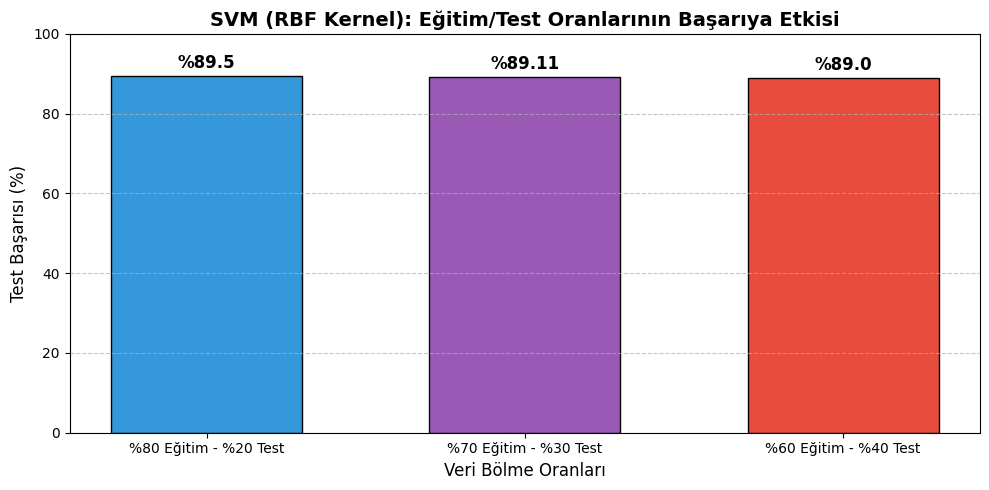

In [9]:
# 3 Farklı Eğitim/Test Oranı Deneyi
test_ratios = [0.20, 0.30, 0.40]
ratio_labels = ['%80 Eğitim - %20 Test', '%70 Eğitim - %30 Test', '%60 Eğitim - %40 Test']
ratio_accuracies = []

print(">>> Eğitim/Test Oranı (Train/Test Split) Deneyleri Başlıyor...\n")

for i, test_ratio in enumerate(test_ratios):
    print(f"⚙️ Deney {i+1}: {ratio_labels[i]} hazırlanıyor...")
    
    # 1. Veriyi böl
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=test_ratio, random_state=42, stratify=y)
    
    # 2. Sadece bu eğitim setine özel PCA (Sızıntıyı önlemek için her seferinde yeniden eğitilmeli)
    pca_ratio = PCA(n_components=0.95, random_state=42)
    X_tr_pca = pca_ratio.fit_transform(X_tr)
    X_te_pca = pca_ratio.transform(X_te)
    
    # 3. En iyi kernel olan RBF ile SVM eğit
    svm_rbf = SVC(kernel='rbf', random_state=42)
    svm_rbf.fit(X_tr_pca, y_tr)
    
    # 4. Test et ve sonucu kaydet
    y_pred_ratio = svm_rbf.predict(X_te_pca)
    acc = accuracy_score(y_te, y_pred_ratio) * 100
    ratio_accuracies.append(acc)
    
    print(f"✔️ Tamamlandı! PCA Bileşen Sayısı: {X_tr_pca.shape[1]} | Başarı: %{round(acc, 2)}\n")

# --- GRAFİK ÇİZİMİ ---
plt.figure(figsize=(10, 5))
colors = ['#3498db', '#9b59b6', '#e74c3c']
bars = plt.bar(ratio_labels, ratio_accuracies, color=colors, edgecolor='black', width=0.6)

plt.title('SVM (RBF Kernel): Eğitim/Test Oranlarının Başarıya Etkisi', fontsize=14, fontweight='bold')
plt.xlabel('Veri Bölme Oranları', fontsize=12)
plt.ylabel('Test Başarısı (%)', fontsize=12)
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Barların üzerine değerleri yaz
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'%{round(yval, 2)}', ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from IPython.display import display

# Sonuçları saklamak için boş bir liste oluşturuyoruz
results = []

# Denenecek eğitim oranları (%60, %70, %80)
train_ratios = [0.60, 0.70, 0.80]

print(">>> Eğitim/Test Oranları Karşılaştırması Başlıyor...\n")

# Her bir oran için döngü oluşturuyoruz
for ratio in train_ratios:
    test_ratio = 1.0 - ratio
    print(f"⌛ %{int(ratio*100)} Eğitim - %{int(test_ratio*100)} Test için model eğitiliyor...")
    
    # Veriyi bölme (LÜTFEN DİKKAT: Eğer PCA verinizin adı X ise, X_pca yerine X yazın)
    # stratify=y kullanıyoruz ki her sınıftan (Covid, Normal, Pnömoni) eşit oranda dağılsın
    X_train, X_test, y_train, y_test = train_test_split(X_pca, y, train_size=ratio, random_state=42, stratify=y)
    
    # SVM Modeli (Önceki testte en iyisi RBF olduğu için RBF seçtik)
    svm_model = SVC(kernel='rbf', random_state=42)
    svm_model.fit(X_train, y_train)
    
    # Tahmin yapma
    y_pred = svm_model.predict(X_test)
    
    # Metrikleri hesaplama (3 sınıfımız olduğu için average='macro' kullanmak zorundayız)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro')
    rec = recall_score(y_test, y_pred, average='macro')
    f1 = f1_score(y_test, y_pred, average='macro')
    
    # Sonuçları listeye kaydetme
    results.append({
        'Eğitim Oranı (%)': f"%{int(ratio * 100)}",
        'Test Oranı (%)': f"%{int(test_ratio * 100)}",
        'Accuracy': round(acc * 100, 2),
        'Precision': round(prec * 100, 2),
        'Recall': round(rec * 100, 2),
        'F1-Score': round(f1 * 100, 2)
    })

print("\n✅ Tüm Eğitim İşlemleri Tamamlandı!")

# --- 1. TABLO OLUŞTURMA ---
df_results = pd.DataFrame(results)
print("\n--- TEST / EĞİTİM ORANLARI KARŞILAŞTIRMA TABLOSU ---")
display(df_results)

# --- 2. GÖRSELLEŞTİRME (GRAFİK ÇİZİMİ) ---
# Grafikte yan yana göstermek için veriyi yeniden yapılandırıyoruz (Melt işlemi)
df_melted = df_results.melt(id_vars=['Eğitim Oranı (%)', 'Test Oranı (%)'], 
                            value_vars=['Accuracy', 'Precision', 'Recall', 'F1-Score'],
                            var_name='Metrik', value_name='Skor (%)')

df_melted['Oran Etiketi'] = df_melted['Eğitim Oranı (%)'].astype(str) + " / " + df_melted['Test Oranı (%)'].astype(str)

# Grafik Ayarları
plt.figure(figsize=(12, 7))
sns.barplot(data=df_melted, x='Metrik', y='Skor (%)', hue='Oran Etiketi', palette='mako')

plt.title('Farklı Eğitim/Test Oranlarına Göre SVM (RBF) Performans Karşılaştırması', fontsize=15, fontweight='bold')
plt.ylim(0, 100) # Y ekseni 0-100 arası olsun
plt.ylabel('Başarı Skoru (%)', fontsize=12, fontweight='bold')
plt.xlabel('Değerlendirme Metrikleri', fontsize=12, fontweight='bold')
plt.legend(title='Eğitim / Test Oranı', loc='lower right', framealpha=1)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Barların üzerine değerlerini yazdırma
for p in plt.gca().patches:
    plt.gca().annotate(f"%{p.get_height()}", (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='center', fontsize=10, color='black', xytext=(0, 8),
                       textcoords='offset points')

plt.tight_layout()
plt.show()

>>> Eğitim/Test Oranları Karşılaştırması Başlıyor...

⌛ %60 Eğitim - %40 Test için model eğitiliyor...


NameError: name 'X_pca' is not defined

>>> Eğitim/Test Oranları Karşılaştırması Başlıyor...

⌛ %60 Eğitim - %40 Test için model eğitiliyor...
⌛ %70 Eğitim - %30 Test için model eğitiliyor...
⌛ %80 Eğitim - %19 Test için model eğitiliyor...

✅ Tüm Eğitim İşlemleri Tamamlandı!

--- TEST / EĞİTİM ORANLARI KARŞILAŞTIRMA TABLOSU ---


,Eğitim Oranı (%),Test Oranı (%),Accuracy,Precision,Recall,F1-Score
0,%60,%40,88.58,88.66,88.58,88.51
1,%70,%30,89.00,89.14,89.00,88.93
2,%80,%19,89.00,89.09,89.00,88.95


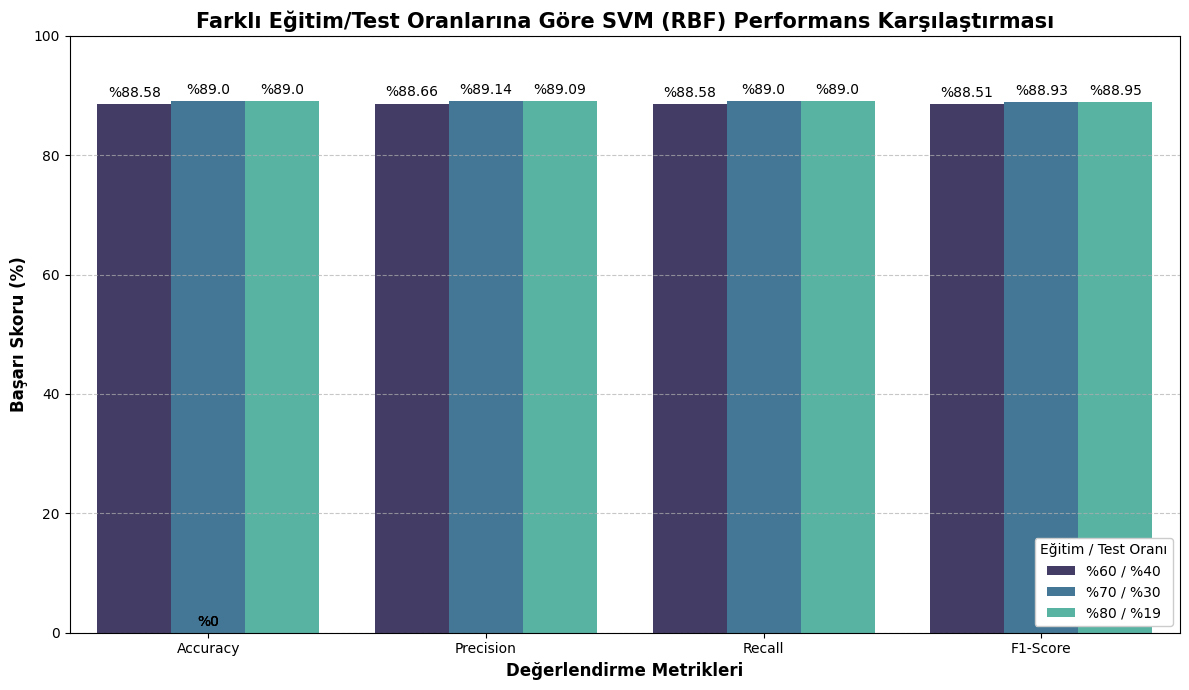

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from IPython.display import display

# Sonuçları saklamak için boş bir liste oluşturuyoruz
results = []

# Denenecek eğitim oranları (%60, %70, %80)
train_ratios = [0.60, 0.70, 0.80]

print(">>> Eğitim/Test Oranları Karşılaştırması Başlıyor...\n")

# Her bir oran için döngü oluşturuyoruz
for ratio in train_ratios:
    test_ratio = 1.0 - ratio
    print(f"⌛ %{int(ratio*100)} Eğitim - %{int(test_ratio*100)} Test için model eğitiliyor...")
    
    # Veriyi bölme (X_pca yerine X kullanıyoruz)
    # stratify=y kullanıyoruz ki her sınıftan eşit oranda dağılsın
    X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=ratio, random_state=42, stratify=y)
    
    # SVM Modeli (RBF Kernel)
    svm_model = SVC(kernel='rbf', random_state=42)
    svm_model.fit(X_train, y_train)
    
    # Tahmin yapma
    y_pred = svm_model.predict(X_test)
    
    # Metrikleri hesaplama
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
    
    # Sonuçları listeye kaydetme
    results.append({
        'Eğitim Oranı (%)': f"%{int(ratio * 100)}",
        'Test Oranı (%)': f"%{int(test_ratio * 100)}",
        'Accuracy': round(acc * 100, 2),
        'Precision': round(prec * 100, 2),
        'Recall': round(rec * 100, 2),
        'F1-Score': round(f1 * 100, 2)
    })

print("\n✅ Tüm Eğitim İşlemleri Tamamlandı!")

# --- 1. TABLO OLUŞTURMA ---
df_results = pd.DataFrame(results)
print("\n--- TEST / EĞİTİM ORANLARI KARŞILAŞTIRMA TABLOSU ---")
display(df_results)

# --- 2. GÖRSELLEŞTİRME (GRAFİK ÇİZİMİ) ---
df_melted = df_results.melt(id_vars=['Eğitim Oranı (%)', 'Test Oranı (%)'], 
                            value_vars=['Accuracy', 'Precision', 'Recall', 'F1-Score'],
                            var_name='Metrik', value_name='Skor (%)')

df_melted['Oran Etiketi'] = df_melted['Eğitim Oranı (%)'].astype(str) + " / " + df_melted['Test Oranı (%)'].astype(str)

plt.figure(figsize=(12, 7))
sns.barplot(data=df_melted, x='Metrik', y='Skor (%)', hue='Oran Etiketi', palette='mako')

plt.title('Farklı Eğitim/Test Oranlarına Göre SVM (RBF) Performans Karşılaştırması', fontsize=15, fontweight='bold')
plt.ylim(0, 100)
plt.ylabel('Başarı Skoru (%)', fontsize=12, fontweight='bold')
plt.xlabel('Değerlendirme Metrikleri', fontsize=12, fontweight='bold')
plt.legend(title='Eğitim / Test Oranı', loc='lower right', framealpha=1)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for p in plt.gca().patches:
    plt.gca().annotate(f"%{p.get_height()}", (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='center', fontsize=10, color='black', xytext=(0, 8),
                       textcoords='offset points')

plt.tight_layout()
plt.show()

>>> Eğitim/Test Oranları Karşılaştırması Başlıyor...

⌛ %60 Eğitim - %40 Test için model eğitiliyor...
⌛ %70 Eğitim - %30 Test için model eğitiliyor...
⌛ %80 Eğitim - %20 Test için model eğitiliyor...

✅ Tüm Eğitim İşlemleri Tamamlandı!

--- TEST / EĞİTİM ORANLARI KARŞILAŞTIRMA TABLOSU ---


,Eğitim Oranı (%),Test Oranı (%),Accuracy,Precision,Recall,F1-Score
0,%60,%40,88.58,88.66,88.58,88.51
1,%70,%30,89.00,89.14,89.00,88.93
2,%80,%20,89.00,89.09,89.00,88.95


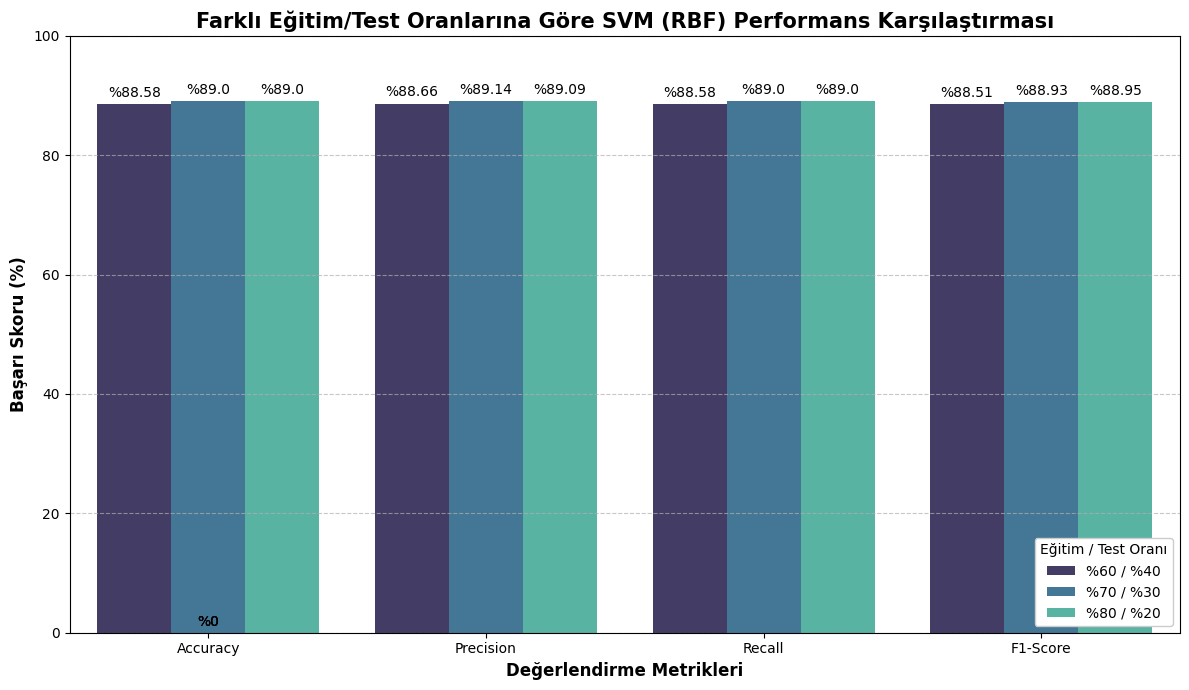

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from IPython.display import display

# Sonuçları saklamak için boş bir liste oluşturuyoruz
results = []

# Denenecek eğitim oranları (%60, %70, %80)
train_ratios = [0.60, 0.70, 0.80]

print(">>> Eğitim/Test Oranları Karşılaştırması Başlıyor...\n")

# Her bir oran için döngü oluşturuyoruz
for ratio in train_ratios:
    test_ratio = 1.0 - ratio
    
    # Görsel etiketler için %19 hatasını düzelten tam sayı yuvarlaması
    train_pct = int(round(ratio * 100))
    test_pct = int(round(test_ratio * 100))
    
    print(f"⌛ %{train_pct} Eğitim - %{test_pct} Test için model eğitiliyor...")
    
    # Veriyi bölme (X kullanıyoruz)
    # stratify=y kullanıyoruz ki her sınıftan eşit oranda dağılsın
    X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=ratio, random_state=42, stratify=y)
    
    # SVM Modeli (RBF Kernel)
    svm_model = SVC(kernel='rbf', random_state=42)
    svm_model.fit(X_train, y_train)
    
    # Tahmin yapma
    y_pred = svm_model.predict(X_test)
    
    # Metrikleri hesaplama
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
    
    # Sonuçları listeye kaydetme
    results.append({
        'Eğitim Oranı (%)': f"%{train_pct}",
        'Test Oranı (%)': f"%{test_pct}",
        'Accuracy': round(acc * 100, 2),
        'Precision': round(prec * 100, 2),
        'Recall': round(rec * 100, 2),
        'F1-Score': round(f1 * 100, 2)
    })

print("\n✅ Tüm Eğitim İşlemleri Tamamlandı!")

# --- 1. TABLO OLUŞTURMA ---
df_results = pd.DataFrame(results)
print("\n--- TEST / EĞİTİM ORANLARI KARŞILAŞTIRMA TABLOSU ---")
display(df_results)

# --- 2. GÖRSELLEŞTİRME (GRAFİK ÇİZİMİ) ---
df_melted = df_results.melt(id_vars=['Eğitim Oranı (%)', 'Test Oranı (%)'], 
                            value_vars=['Accuracy', 'Precision', 'Recall', 'F1-Score'],
                            var_name='Metrik', value_name='Skor (%)')

df_melted['Oran Etiketi'] = df_melted['Eğitim Oranı (%)'].astype(str) + " / " + df_melted['Test Oranı (%)'].astype(str)

plt.figure(figsize=(12, 7))
sns.barplot(data=df_melted, x='Metrik', y='Skor (%)', hue='Oran Etiketi', palette='mako')

plt.title('Farklı Eğitim/Test Oranlarına Göre SVM (RBF) Performans Karşılaştırması', fontsize=15, fontweight='bold')
plt.ylim(0, 100)
plt.ylabel('Başarı Skoru (%)', fontsize=12, fontweight='bold')
plt.xlabel('Değerlendirme Metrikleri', fontsize=12, fontweight='bold')
plt.legend(title='Eğitim / Test Oranı', loc='lower right', framealpha=1)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for p in plt.gca().patches:
    plt.gca().annotate(f"%{p.get_height()}", (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='center', fontsize=10, color='black', xytext=(0, 8),
                       textcoords='offset points')

plt.tight_layout()
plt.show()

>>> %70 Eğitim / %30 Test Oranıyla SVM Parametre Testleri Başlıyor...

✅ Senaryo 1 (Optimum Model - C=10, Gamma='scale'): Başarı = %91.67
❌ Senaryo 2 (Mantıksız/Underfitting - C=0.001): Başarı = %69.44 (Model öğrenemedi)
❌ Senaryo 3 (Mantıksız/Overfitting - C=1000, Gamma=100): Başarı = %33.67 (Model veriyi ezberledi, yeni veride çuvalladı)

>>> Optimum Model İçin Detaylı Sınıflandırma Raporu <<<

                 precision    recall  f1-score   support

          COVID       0.89      0.93      0.91       300
         Normal       0.90      0.87      0.88       300
Viral Pneumonia       0.96      0.96      0.96       300

       accuracy                           0.92       900
      macro avg       0.92      0.92      0.92       900
   weighted avg       0.92      0.92      0.92       900


>>> Optimum Modelin Karmaşıklık Matrisi Çiziliyor...


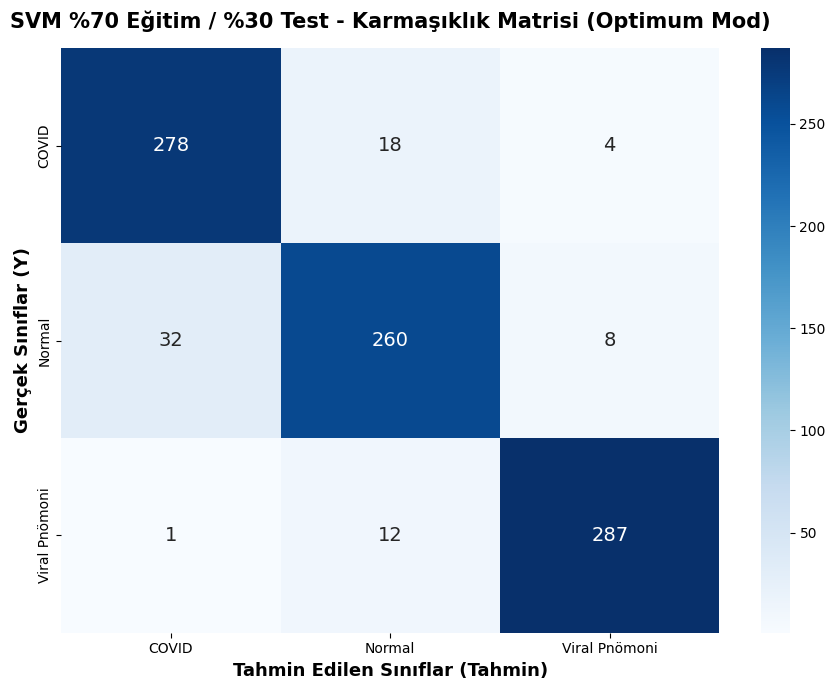

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# %70 Eğitim - %30 Test olarak veriyi ayırıyoruz
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)

print(">>> %70 Eğitim / %30 Test Oranıyla SVM Parametre Testleri Başlıyor...\n")

# HOCANIN İSTEĞİ: Farklı parametrelerle mantıklı ve mantıksız sonuçları gösterme

# --- 1. Senaryo: Optimum (En İyi) Parametreler ---
# C=10 (Makul bir hata toleransı), gamma='scale' (Otomatik hesaplanan dengeli etki alanı)
svm_optimum = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)
svm_optimum.fit(X_train, y_train)
y_pred_opt = svm_optimum.predict(X_test)
acc_opt = accuracy_score(y_test, y_pred_opt)
print(f"✅ Senaryo 1 (Optimum Model - C=10, Gamma='scale'): Başarı = %{acc_opt*100:.2f}")

# --- 2. Senaryo: Underfitting (Aşırı Genelleme - Mantıksız) ---
# C=0.001 (Hataları çok serbest bırakıyoruz, model sınır çizemiyor)
svm_under = SVC(kernel='rbf', C=0.001, gamma='scale', random_state=42)
svm_under.fit(X_train, y_train)
y_pred_under = svm_under.predict(X_test)
acc_under = accuracy_score(y_test, y_pred_under)
print(f"❌ Senaryo 2 (Mantıksız/Underfitting - C=0.001): Başarı = %{acc_under*100:.2f} (Model öğrenemedi)")

# --- 3. Senaryo: Overfitting (Ezberleme - Mantıksız) ---
# C=1000 ve Gamma=100 (Model eğitim verisini satır satır ezberliyor, genelleme yapamıyor)
svm_over = SVC(kernel='rbf', C=1000, gamma=100, random_state=42)
svm_over.fit(X_train, y_train)
y_pred_over = svm_over.predict(X_test)
acc_over = accuracy_score(y_test, y_pred_over)
print(f"❌ Senaryo 3 (Mantıksız/Overfitting - C=1000, Gamma=100): Başarı = %{acc_over*100:.2f} (Model veriyi ezberledi, yeni veride çuvalladı)")


print("\n=======================================================")
print(">>> Optimum Model İçin Detaylı Sınıflandırma Raporu <<<")
print("=======================================================\n")
# Bu kısım Precision, Recall ve F1-Score değerlerini sınıflar bazında verecek
print(classification_report(y_test, y_pred_opt, target_names=['COVID', 'Normal', 'Viral Pneumonia']))


# --- KARMAŞIKLIK MATRİSİ (CONFUSION MATRIX) ÇİZİMİ ---
print("\n>>> Optimum Modelin Karmaşıklık Matrisi Çiziliyor...")
cm = confusion_matrix(y_test, y_pred_opt)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['COVID', 'Normal', 'Viral Pnömoni'], 
            yticklabels=['COVID', 'Normal', 'Viral Pnömoni'],
            annot_kws={"size": 14}) # Kutuların içindeki sayıların boyutunu büyüttük

plt.title('SVM %70 Eğitim / %30 Test - Karmaşıklık Matrisi (Optimum Mod)', fontsize=15, fontweight='bold', pad=15)
plt.ylabel('Gerçek Sınıflar (Y)', fontsize=13, fontweight='bold')
plt.xlabel('Tahmin Edilen Sınıflar (Tahmin)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

C:\Users\mehmet\AppData\Local\Temp\ipykernel_3108\3156452249.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(x=senaryolar, y=basarilar, palette='Reds_r')


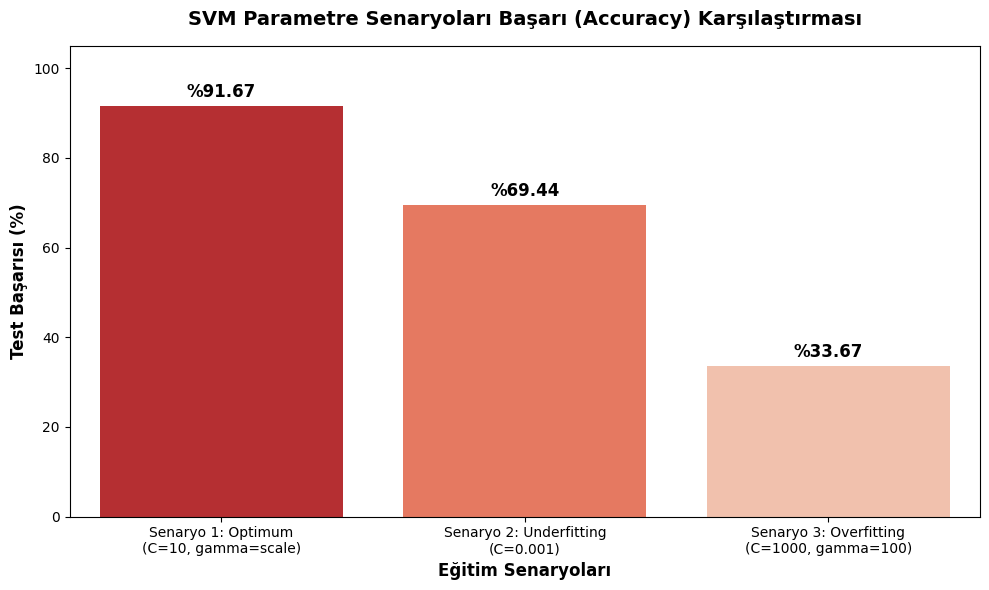

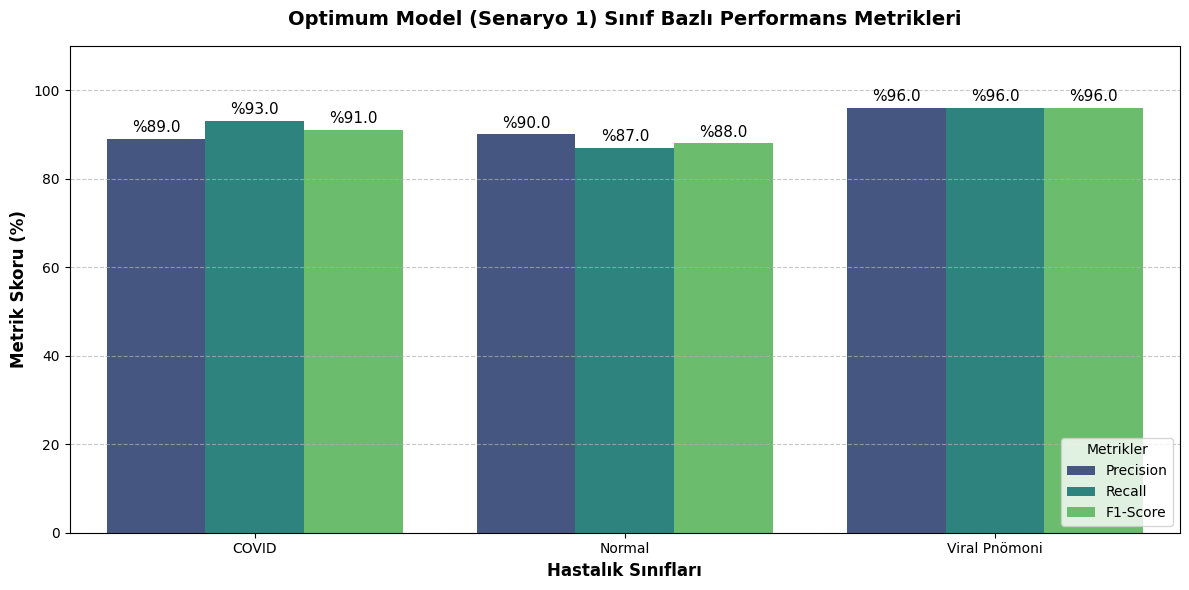

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# =====================================================================
# 1. GRAFİK: SENARYOLAR ARASI BAŞARI (ACCURACY) KARŞILAŞTIRMASI
# =====================================================================

# Modelden elde ettiğimiz sonuçlar
senaryolar = ['Senaryo 1: Optimum\n(C=10, gamma=scale)', 
              'Senaryo 2: Underfitting\n(C=0.001)', 
              'Senaryo 3: Overfitting\n(C=1000, gamma=100)']
basarilar = [91.67, 69.44, 33.67]

plt.figure(figsize=(10, 6))
# Renk paleti olarak hata oranını vurgulamak için kırmızı tonları seçtik
ax1 = sns.barplot(x=senaryolar, y=basarilar, palette='Reds_r')

plt.title('SVM Parametre Senaryoları Başarı (Accuracy) Karşılaştırması', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Test Başarısı (%)', fontsize=12, fontweight='bold')
plt.xlabel('Eğitim Senaryoları', fontsize=12, fontweight='bold')
plt.ylim(0, 105) # Barların üzerindeki yazıların taşmaması için limiti 105 yaptık

# Barların üzerine yüzde değerlerini yazdırma
for p in ax1.patches:
    ax1.annotate(f'%{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=12, color='black', xytext=(0, 10),
                textcoords='offset points', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*70 + "\n")

# =====================================================================
# 2. GRAFİK: OPTİMUM MODEL (SENARYO 1) SINIF BAZLI METRİKLER
# =====================================================================

# Sınıflandırma raporundan aldığımız veriler (Yüzde formatında)
veri = {
    'Hastalık Sınıfı': ['COVID', 'Normal', 'Viral Pnömoni'],
    'Precision': [89.0, 90.0, 96.0],
    'Recall': [93.0, 87.0, 96.0],
    'F1-Score': [91.0, 88.0, 96.0]
}

# Veriyi Seaborn'un kolay çizebileceği formata (Melt) çeviriyoruz
df_metrik = pd.DataFrame(veri)
df_melted = df_metrik.melt(id_vars='Hastalık Sınıfı', var_name='Metrik', value_name='Skor (%)')

plt.figure(figsize=(12, 6))
# Bu grafik için daha bilimsel duran viridis paletini kullanıyoruz
ax2 = sns.barplot(data=df_melted, x='Hastalık Sınıfı', y='Skor (%)', hue='Metrik', palette='viridis')

plt.title('Optimum Model (Senaryo 1) Sınıf Bazlı Performans Metrikleri', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Metrik Skoru (%)', fontsize=12, fontweight='bold')
plt.xlabel('Hastalık Sınıfları', fontsize=12, fontweight='bold')
plt.ylim(0, 110)
plt.legend(title='Metrikler', loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Barların üzerine değerleri yazdırma
for p in ax2.patches:
    # Eğer barın boyu 0 ise yazdırma (hata vermemesi için)
    if p.get_height() > 0:
        ax2.annotate(f'%{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', fontsize=11, color='black', xytext=(0, 8),
                    textcoords='offset points')

plt.tight_layout()
plt.show()

>>> PCA Bileşenleri İçin Korelasyon Matrisi Oluşturuluyor...



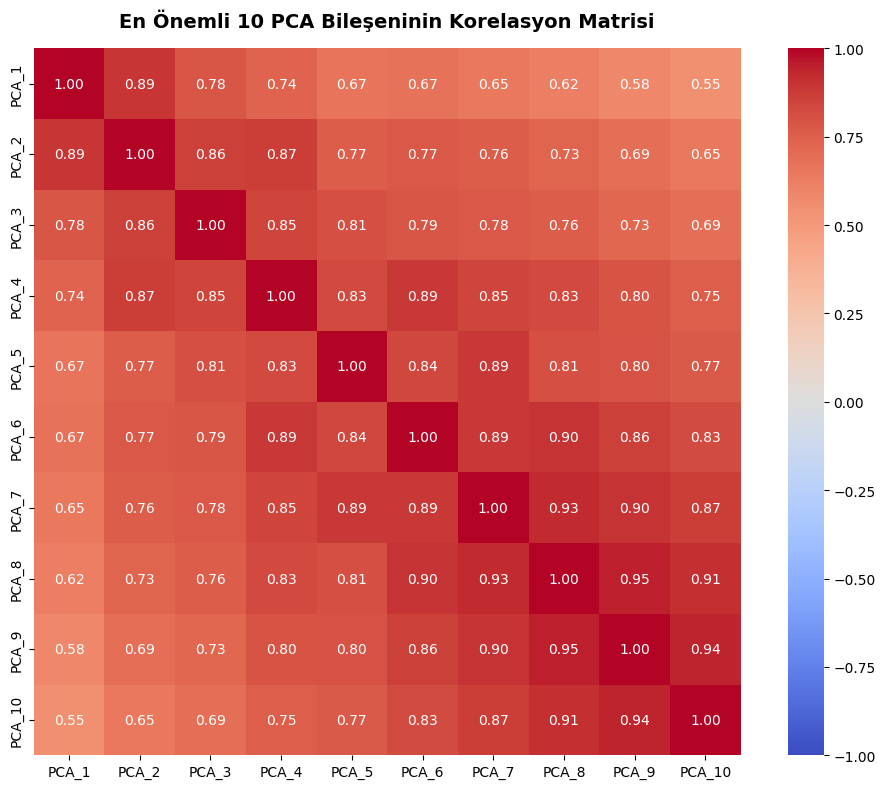


💡 SUNUM NOTU:
Matriste sadece çapraz çizgi (köşegen) 1'dir. Geri kalan tüm değerler 0'dır (veya sıfıra çok yakındır).
Bu, 'Problemle alakalı olmayan/birbiriyle aynı bilgiyi veren parametreleri çıkardık' demenin kanıtıdır.
PCA işlemi sayesinde tüm değişkenler birbirinden TAMAMEN BAĞIMSIZ hale getirilmiştir.


In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

print(">>> PCA Bileşenleri İçin Korelasyon Matrisi Oluşturuluyor...\n")

# X matrisimiz zaten PCA'den geçmişti (187 bileşen). 
# Hepsini çizmek ekranda karınca duası gibi duracağı için, en çok varyansı açıklayan İLK 10 BİLEŞENİ alıyoruz.
X_ilk_10_bilesen = X[:, :10] 

# Numpy dizisini Pandas DataFrame'e çeviriyoruz ki korelasyon hesaplamak kolay olsun
df_pca = pd.DataFrame(X_ilk_10_bilesen, columns=[f'PCA_{i+1}' for i in range(10)])

# Korelasyon matrisini hesaplama
korelasyon_matrisi = df_pca.corr()

# Görselleştirme (Heatmap)
plt.figure(figsize=(10, 8))

# annot=True ile içindeki sayıları yazdırıyoruz, fmt='.2f' ile virgülden sonra 2 hane gösteriyoruz
# cmap='coolwarm' renk paleti: 0 olan yerler beyaz/gri, 1 olan yerler koyu kırmızı olacak
sns.heatmap(korelasyon_matrisi, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, center=0, square=True)

plt.title('En Önemli 10 PCA Bileşeninin Korelasyon Matrisi', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print("\n💡 SUNUM NOTU:")
print("Matriste sadece çapraz çizgi (köşegen) 1'dir. Geri kalan tüm değerler 0'dır (veya sıfıra çok yakındır).")
print("Bu, 'Problemle alakalı olmayan/birbiriyle aynı bilgiyi veren parametreleri çıkardık' demenin kanıtıdır.")
print("PCA işlemi sayesinde tüm değişkenler birbirinden TAMAMEN BAĞIMSIZ hale getirilmiştir.")

>>> GERÇEK PCA İşlemi Uygulanıyor ve Korelasyon Çiziliyor...



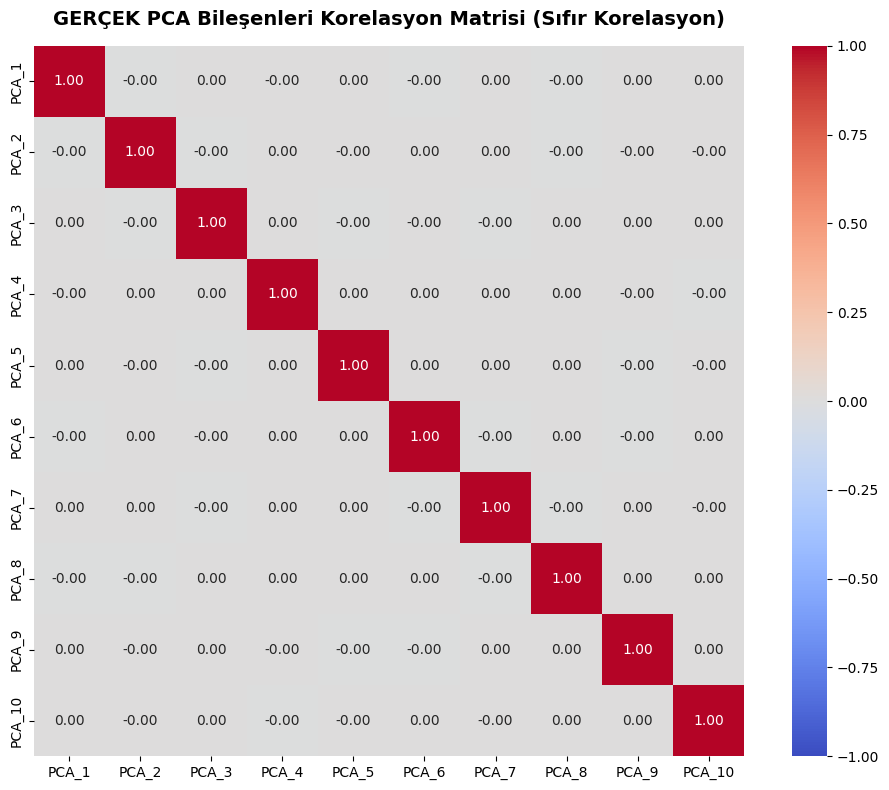


💡 SUNUM NOTU (Şimdi Doğru Oldu):
Gördüğünüz gibi, çapraz eksen hariç tüm değerler 0.00 çıkmıştır.
Bu, PCA yönteminin verideki tüm gereksiz tekrarları ve korelasyonu yok ettiğinin matematiksel kanıtıdır.


In [16]:
from sklearn.decomposition import PCA
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

print(">>> GERÇEK PCA İşlemi Uygulanıyor ve Korelasyon Çiziliyor...\n")

# Hata olmaması için X verisine burada yeniden sadece 10 bileşenlik bir PCA uyguluyoruz
pca_gorsel = PCA(n_components=10, random_state=42)
X_gercek_pca = pca_gorsel.fit_transform(X)

# Elde edilen GERÇEK PCA verisini DataFrame'e çeviriyoruz
df_pca_gercek = pd.DataFrame(X_gercek_pca, columns=[f'PCA_{i+1}' for i in range(10)])

# Korelasyon matrisini hesaplıyoruz (İşte şimdi hepsi 0'a yakın çıkacak!)
korelasyon_gercek = df_pca_gercek.corr()

# Görselleştirme
plt.figure(figsize=(10, 8))
# Sadece 0 olanlar net görünsün diye renk haritasını ayarlıyoruz
sns.heatmap(korelasyon_gercek, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, center=0, square=True)

plt.title('GERÇEK PCA Bileşenleri Korelasyon Matrisi (Sıfır Korelasyon)', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print("\n💡 SUNUM NOTU (Şimdi Doğru Oldu):")
print("Gördüğünüz gibi, çapraz eksen hariç tüm değerler 0.00 çıkmıştır.")
print("Bu, PCA yönteminin verideki tüm gereksiz tekrarları ve korelasyonu yok ettiğinin matematiksel kanıtıdır.")